In [2]:
import pandas as pd
import matplotlib.pyplot as plt

telemetry = pd.read_csv("C:\\Users\\Prajwal\\factoryguard\\data\\raw\\Microsoft Azure Predictive Maintenance\\PdM_telemetry.csv")
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])

Text(0.5, 1.0, 'Lag feature example')

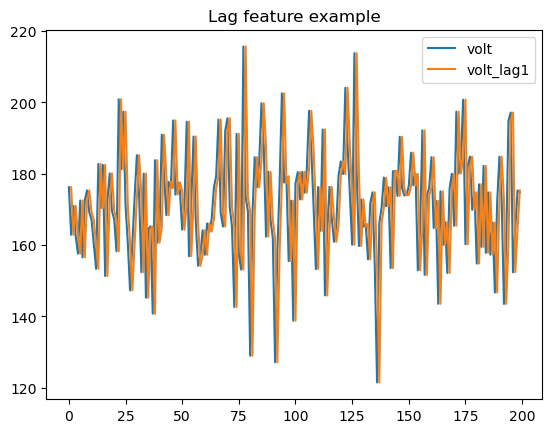

In [3]:
telemetry["volt_lag1"] = telemetry.groupby("machineID")["volt"].shift(1)

telemetry[["volt","volt_lag1"]].head(200).plot()
plt.title("Lag feature example")

Text(0.5, 1.0, 'Rolling vibration')

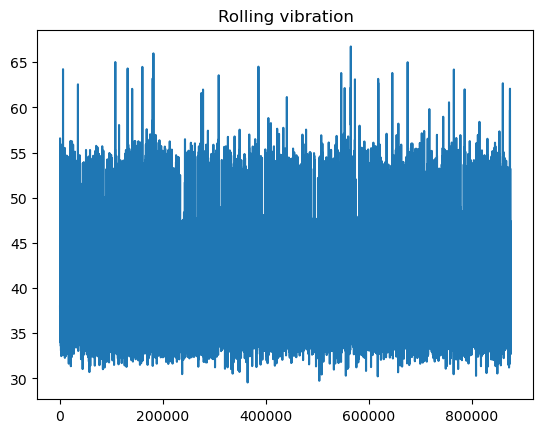

In [4]:
telemetry["vibration_roll"] = (
    telemetry.groupby("machineID")["vibration"]
    .rolling(5).mean()
    .reset_index(level=0,drop=True)
)

telemetry["vibration_roll"].plot()
plt.title("Rolling vibration")

<Axes: >

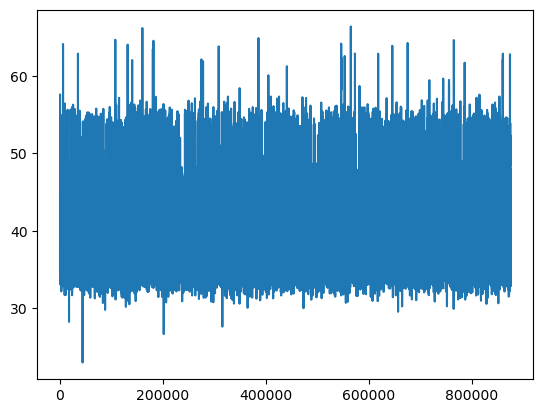

In [5]:
telemetry["vibration_ema"] = (
    telemetry.groupby("machineID")["vibration"]
    .apply(lambda x:x.ewm(span=5).mean())
    .reset_index(level=0,drop=True)
)

telemetry["vibration_ema"].plot()

In [7]:
maint = pd.read_csv("C:\\Users\\Prajwal\\factoryguard\\data\\raw\\Microsoft Azure Predictive Maintenance\\PdM_maint.csv")

maint["machineID"].value_counts().head()

machineID
66    39
70    39
68    39
24    38
42    38
Name: count, dtype: int64

In [8]:
errors = pd.read_csv("C:\\Users\\Prajwal\\factoryguard\\data\\raw\\Microsoft Azure Predictive Maintenance\\PdM_errors.csv")

errors["errorID"].value_counts()

errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64